# Checkpoint 4 -- Diarization: Model Comparison

**Models:**
- `pyannote/speaker-diarization-community-1`
- `nvidia/diar_streaming_sortformer_4spk-v2.1`

**Datasets:**
- `AMI Meeting Corpus`, IHM test subset
- `VoxConverse`, test subset


## 0. Setup

In [ ]:
from pathlib import Path
import os
import sys
import subprocess

READY = Path("/content/.cp4_diarization_deps_ready")


def run(cmd):
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)


def pip_install(*packages, extra_args=None):
    cmd = [sys.executable, "-m", "pip", "install"]
    if extra_args:
        cmd.extend(extra_args)
    cmd.extend(packages)
    run(cmd)


if not READY.exists():
    run(["apt-get", "update", "-qq"])
    run(["apt-get", "install", "-y", "-qq", "ffmpeg", "libsndfile1", "git-lfs"])
    run(["git", "lfs", "install"])

    subprocess.call([
        sys.executable, "-m", "pip", "uninstall", "-y", "-q",
        "numpy", "scipy", "pandas", "matplotlib", "seaborn", "scikit-learn",
        "numba", "librosa", "pyannote.audio", "pyannote.metrics", "nemo_toolkit",
    ])

    stable_stack = [
        "numpy==1.26.4",
        "scipy==1.13.1",
        "pandas==2.2.2",
        "matplotlib==3.8.4",
        "scikit-learn==1.5.2",
        "numba==0.60.0",
        "soundfile==0.12.1",
        "librosa==0.10.2.post1",
        "datasets==3.6.0",
        "tqdm==4.67.1",
        "requests==2.32.3",
        "huggingface_hub==0.36.0",
    ]
    pip_install(*stable_stack, extra_args=["-q", "--no-cache-dir"])

    # Model libraries. Imports are kept lazy in later cells.
    pip_install("pyannote.audio", extra_args=["-q", "--no-cache-dir"])
    pip_install("Cython", "packaging", extra_args=["-q", "--no-cache-dir"])
    pip_install("git+https://github.com/NVIDIA/NeMo.git@main#egg=nemo_toolkit[asr]", extra_args=["-q", "--no-cache-dir"])

    # Re-assert the numeric stack after model-library installation.
    pip_install(
        "numpy==1.26.4",
        "scipy==1.13.1",
        "pandas==2.2.2",
        "matplotlib==3.8.4",
        extra_args=["-q", "--no-cache-dir", "--force-reinstall"],
    )

    READY.write_text("ok")
    print("Dependencies installed. Restarting runtime now. After restart, run all cells again.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed for this Colab runtime.")

Dependencies already installed for this Colab runtime.


In [ ]:
import os
import gc
import time
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import requests
import torch
from datasets import load_dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("torch", torch.__version__)

numpy 1.26.4
pandas 2.2.2
torch 2.10.0+cu128


In [ ]:
SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TARGET_SR = 16_000
TARGET_SUBTYPE = "PCM_16"
PEAK_TARGET = 0.9

BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"
RTTM_DIR = BASE_DIR / "data" / "rttm"
BASELINE_DIR = BASE_DIR / "data" / "baselines" / "diarization"
VIS_DIR = BASE_DIR / "data" / "baselines" / "visuals" / "diarization"

for d in [PROCESSED_DIR, MANIFEST_DIR, RTTM_DIR, BASELINE_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

device: cuda
NVIDIA A100-SXM4-80GB


In [ ]:
os.environ['HF_TOKEN'] = ''

In [ ]:
MAX_RECORDINGS_PER_DATASET = 8
SORTFORMER_SUPPORTED_ONLY = False

HF_TOKEN = os.environ.get("HF_TOKEN", "")
if not HF_TOKEN:
    print("Set HF_TOKEN before loading gated models. Example: os.environ['HF_TOKEN'] = 'hf_...' ")

## 1. Metrics

The notebook computes frame-based approximations of DER and JER directly from RTTM files. This avoids importing `pyannote.metrics` and makes the notebook less sensitive to dependency conflicts. The frame step is configurable. A 20 ms step gives more accurate scores, while a 100 ms step is faster for debugging.

DER is decomposed into missed speech, false alarm, and speaker confusion after optimal speaker-label mapping. JER is computed as the mean speaker-level Jaccard error over reference speakers.

In [ ]:
FRAME_STEP = 0.05

def read_rttm_df(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or not line.startswith("SPEAKER"):
                continue
            parts = line.split()
            start = float(parts[3])
            duration = float(parts[4])
            rows.append({
                "file_id": parts[1],
                "start": start,
                "end": start + duration,
                "duration": duration,
                "speaker": parts[7],
            })
    return pd.DataFrame(rows)


def write_segments_rttm(segments, path: Path, uri: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        for start, end, speaker in segments:
            if end <= start:
                continue
            f.write(f"SPEAKER {uri} 1 {start:.3f} {end - start:.3f} <NA> <NA> {speaker} <NA> <NA>\n")


def frame_matrix(df: pd.DataFrame, speakers: list[str], duration: float, step: float = FRAME_STEP) -> np.ndarray:
    n_frames = int(np.ceil(duration / step))
    mat = np.zeros((len(speakers), n_frames), dtype=np.int16)
    spk_to_idx = {s: i for i, s in enumerate(speakers)}
    for _, r in df.iterrows():
        i = spk_to_idx[r["speaker"]]
        a = max(0, int(np.floor(r["start"] / step)))
        b = min(n_frames, int(np.ceil(r["end"] / step)))
        mat[i, a:b] = 1
    return mat


def optimal_mapping(ref_mat: np.ndarray, hyp_mat: np.ndarray):
    if ref_mat.shape[0] == 0 or hyp_mat.shape[0] == 0:
        return []
    from scipy.optimize import linear_sum_assignment
    overlap = ref_mat @ hyp_mat.T
    rows, cols = linear_sum_assignment(-overlap)
    return list(zip(rows, cols))


def score_pair(reference_path: Path, hypothesis_path: Path, duration_sec: float, step: float = FRAME_STEP) -> dict:
    ref_df = read_rttm_df(reference_path)
    hyp_df = read_rttm_df(hypothesis_path)

    ref_speakers = sorted(ref_df["speaker"].unique()) if not ref_df.empty else []
    hyp_speakers = sorted(hyp_df["speaker"].unique()) if not hyp_df.empty else []

    ref = frame_matrix(ref_df, ref_speakers, duration_sec, step)
    hyp = frame_matrix(hyp_df, hyp_speakers, duration_sec, step)

    mapping = optimal_mapping(ref, hyp)
    mapped_hyp = np.zeros_like(ref)
    for ri, hi in mapping:
        mapped_hyp[ri] = hyp[hi]

    ref_count = ref.sum(axis=0).astype(np.int32)
    hyp_count = hyp.sum(axis=0).astype(np.int32) if hyp.size else np.zeros(ref.shape[1], dtype=np.uint8)
    correct = (ref & mapped_hyp).sum(axis=0).astype(np.int32) if ref.size else np.zeros(ref.shape[1], dtype=np.uint8)

    total = ref_count.sum() * step
    missed = np.maximum(ref_count - hyp_count, 0).sum() * step
    false_alarm = np.maximum(hyp_count - ref_count, 0).sum() * step
    confusion = (np.minimum(ref_count, hyp_count) - correct).clip(min=0).sum() * step
    der = (missed + false_alarm + confusion) / total if total > 0 else np.nan

    jaccards = []
    for ri in range(ref.shape[0]):
        best = 0.0
        for hi in range(hyp.shape[0]):
            inter = np.logical_and(ref[ri], hyp[hi]).sum()
            union = np.logical_or(ref[ri], hyp[hi]).sum()
            if union > 0:
                best = max(best, inter / union)
        jaccards.append(best)
    jer = 1.0 - float(np.mean(jaccards)) if jaccards else np.nan

    return {
        "der": der,
        "jer": jer,
        "missed_detection": missed / total if total > 0 else np.nan,
        "false_alarm": false_alarm / total if total > 0 else np.nan,
        "confusion": confusion / total if total > 0 else np.nan,
        "total_speaker_time": total,
    }


def summarize_scores(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (model, dataset), g in df.groupby(["model", "dataset"]):
        total_duration = g["duration_sec"].sum()
        total_runtime = g["runtime_sec"].sum()
        rows.append({
            "model": model,
            "dataset": dataset,
            "n_recordings": len(g),
            "total_audio_h": total_duration / 3600,
            "mean_der": g["der"].mean(),
            "median_der": g["der"].median(),
            "mean_jer": g["jer"].mean(),
            "median_jer": g["jer"].median(),
            "speaker_count_acc": (g["ref_speakers"] == g["hyp_speakers"]).mean(),
            "rtf": total_runtime / total_duration if total_duration > 0 else np.nan,
            "rtfx": total_duration / total_runtime if total_runtime > 0 else np.nan,
            "failures": int(g["failed"].sum()) if "failed" in g else 0,
        })
    return pd.DataFrame(rows).sort_values(["dataset", "mean_der", "model"]).reset_index(drop=True)

## 2. Dataset Preparation

The evaluation uses the same two diarization datasets that were selected during data preparation:

- VoxConverse test. This dataset contains real multi-speaker recordings from web video content and is useful for testing open-domain robustness.
- AMI IHM test. This dataset contains meeting recordings from individual headset microphones and is the closest benchmark to the service scenario.

The notebook creates normalized 16 kHz mono WAV files and RTTM references. If manifests already exist, they are reused.

In [ ]:
def preprocess_audio(array: np.ndarray, src_sr: int) -> np.ndarray:
    y = np.asarray(array, dtype=np.float32)
    if y.ndim > 1:
        y = librosa.to_mono(y.T if y.shape[0] > y.shape[1] else y)
    if src_sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=src_sr, target_sr=TARGET_SR)
    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    if peak > 0:
        y = y / peak * PEAK_TARGET
    return y.astype(np.float32)


def save_wav(array: np.ndarray, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), array, TARGET_SR, subtype=TARGET_SUBTYPE)


def parse_voxconverse_sample(sample, file_id: str) -> pd.DataFrame:
    df = pd.DataFrame({
        "file_id": file_id,
        "start": sample["timestamps_start"],
        "end": sample["timestamps_end"],
        "speaker_id": sample["speakers"],
    })
    df["duration"] = df["end"] - df["start"]
    return df.sort_values("start").reset_index(drop=True)


def recording_stats(rttm_df: pd.DataFrame, audio_dur: float) -> dict:
    return {
        "n_speakers": rttm_df["speaker_id"].nunique(),
        "n_segments": len(rttm_df),
        "mean_segment_sec": rttm_df["duration"].mean(),
        "duration_sec": audio_dur,
    }

def manifest_is_usable(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        df = pd.read_csv(path)
    except Exception:
        return False
    if df.empty or "audio_path" not in df or "rttm_path" not in df:
        return False
    return all(Path(x).exists() for x in df["audio_path"]) and all(Path(x).exists() for x in df["rttm_path"])

In [ ]:
def dataframe_to_rttm(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        for _, r in df.iterrows():
            f.write(
                f"SPEAKER {r['file_id']} 1 "
                f"{float(r['start']):.3f} "
                f"{float(r['duration']):.3f} "
                f"<NA> <NA> {r['speaker_id']} <NA> <NA>\n"
            )


In [ ]:
def build_voxconverse_manifest(force: bool = False) -> pd.DataFrame:
    manifest_path = MANIFEST_DIR / "diar_voxconverse_test.csv"
    if manifest_is_usable(manifest_path) and not force:
        return pd.read_csv(manifest_path)

    vc_raw = load_dataset("diarizers-community/voxconverse", split="test", trust_remote_code=True)
    rows = []
    for i, sample in enumerate(tqdm(vc_raw, desc="VoxConverse")):
        file_id = sample.get("audio_id", sample.get("id", f"vc_{i:05d}"))
        audio = sample["audio"]
        y = preprocess_audio(audio["array"], audio["sampling_rate"])
        duration_sec = len(y) / TARGET_SR

        audio_path = PROCESSED_DIR / "voxconverse_test" / f"{file_id}.wav"
        rttm_path = RTTM_DIR / "voxconverse_test" / f"{file_id}.rttm"
        save_wav(y, audio_path)
        rttm_df = parse_voxconverse_sample(sample, file_id)
        dataframe_to_rttm(rttm_df, rttm_path)

        stats = recording_stats(rttm_df, duration_sec)
        rows.append({
            "id": file_id,
            "dataset": "VoxConverse",
            "audio_path": str(audio_path),
            "rttm_path": str(rttm_path),
            **stats,
        })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    return manifest

vox_manifest = build_voxconverse_manifest(force=False)
vox_manifest.head()

VoxConverse:   0%|          | 0/232 [00:00<?, ?it/s]

,id,dataset,audio_path,rttm_path,n_speakers,n_segments,mean_segment_sec,duration_sec
0,vc_00000,VoxConverse,data/processed/voxconverse_test/vc_00000.wav,data/rttm/voxconverse_test/vc_00000.rttm,7,75,14.898533,1200.064
1,vc_00001,VoxConverse,data/processed/voxconverse_test/vc_00001.wav,data/rttm/voxconverse_test/vc_00001.rttm,12,111,10.000360,1200.064
2,vc_00002,VoxConverse,data/processed/voxconverse_test/vc_00002.wav,data/rttm/voxconverse_test/vc_00002.rttm,3,15,27.539333,430.720
3,vc_00003,VoxConverse,data/processed/voxconverse_test/vc_00003.wav,data/rttm/voxconverse_test/vc_00003.rttm,2,166,3.177229,572.224
4,vc_00004,VoxConverse,data/processed/voxconverse_test/vc_00004.wav,data/rttm/voxconverse_test/vc_00004.rttm,9,123,10.211707,1200.064


In [ ]:
def parse_rttm_text_to_df(text: str, file_id: str) -> pd.DataFrame:
    rows = []
    for line in text.splitlines():
        line = line.strip()
        if not line.startswith("SPEAKER"):
            continue
        parts = line.split()
        start = float(parts[3])
        duration = float(parts[4])
        rows.append({
            "file_id": file_id,
            "start": start,
            "duration": duration,
            "end": start + duration,
            "speaker_id": parts[7],
        })
    return pd.DataFrame(rows).sort_values("start").reset_index(drop=True)


def reconstruct_ami_meeting(segments: list[dict]) -> np.ndarray:
    end_sec = max(s["end"] for s in segments)
    out = np.zeros(int(np.ceil(end_sec * TARGET_SR)), dtype=np.float32)
    for s in segments:
        y = preprocess_audio(s["audio_array"], s["src_sr"])
        start = int(round(s["begin"] * TARGET_SR))
        end = min(start + len(y), len(out))
        out[start:end] = y[:end - start]
    return out


def build_ami_manifest(force: bool = False) -> pd.DataFrame:
    manifest_path = MANIFEST_DIR / "diar_ami_test.csv"
    if manifest_is_usable(manifest_path) and not force:
        return pd.read_csv(manifest_path)

    ami_hf = load_dataset("edinburghcstr/ami", "ihm", split="test", trust_remote_code=True)
    base_url = "https://raw.githubusercontent.com/BUTspeechFIT/AMI-diarization-setup/main/only_words/rttms/test"

    hf_segments = defaultdict(list)
    for sample in tqdm(ami_hf, desc="Scanning AMI"):
        mid = sample.get("meeting_id", "unknown")
        hf_segments[mid].append({
            "audio_array": np.asarray(sample["audio"]["array"], dtype=np.float32),
            "src_sr": sample["audio"]["sampling_rate"],
            "begin": float(sample.get("begin_time", 0.0)),
            "end": float(sample.get("end_time", 0.0)),
        })

    rows = []
    for mid, segments in tqdm(sorted(hf_segments.items()), desc="AMI meetings"):
        segments = sorted(segments, key=lambda x: x["begin"])
        r = requests.get(f"{base_url}/{mid}.rttm", timeout=30)
        if r.status_code != 200:
            print(f"Skipping {mid}: RTTM download failed with status {r.status_code}")
            continue

        y = reconstruct_ami_meeting(segments)
        duration_sec = len(y) / TARGET_SR
        audio_path = PROCESSED_DIR / "ami_test" / f"{mid}.wav"
        rttm_path = RTTM_DIR / "ami_butspeechfit" / "ami_test" / f"{mid}.rttm"
        save_wav(y, audio_path)

        rttm_df = parse_rttm_text_to_df(r.text, mid)
        dataframe_to_rttm(rttm_df, rttm_path)
        stats = recording_stats(rttm_df, duration_sec)

        rows.append({
            "id": mid,
            "dataset": "AMI IHM",
            "audio_path": str(audio_path),
            "rttm_path": str(rttm_path),
            **stats,
        })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    return manifest

ami_manifest = build_ami_manifest(force=False)
ami_manifest.head()

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

ihm/train-00000-of-00042.parquet:   0%|          | 0.00/296M [00:00<?, ?B/s]

ihm/train-00001-of-00042.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/13098 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12643 [00:00<?, ? examples/s]

Scanning AMI:   0%|          | 0/12643 [00:00<?, ?it/s]

AMI meetings:   0%|          | 0/16 [00:00<?, ?it/s]

,id,dataset,audio_path,rttm_path,n_speakers,n_segments,mean_segment_sec,duration_sec
0,EN2002a,AMI IHM,data/processed/ami_test/EN2002a.wav,data/rttm/ami_butspeechfit/ami_test/EN2002a.rttm,4,746,3.391769,2142.370125
1,EN2002b,AMI IHM,data/processed/ami_test/EN2002b.wav,data/rttm/ami_butspeechfit/ami_test/EN2002b.rttm,4,490,3.966204,1786.590000
2,EN2002c,AMI IHM,data/processed/ami_test/EN2002c.wav,data/rttm/ami_butspeechfit/ami_test/EN2002c.rttm,3,635,5.265575,2889.639938
3,EN2002d,AMI IHM,data/processed/ami_test/EN2002d.wav,data/rttm/ami_butspeechfit/ami_test/EN2002d.rttm,4,685,3.906409,2207.850125
4,ES2004a,AMI IHM,data/processed/ami_test/ES2004a.wav,data/rttm/ami_butspeechfit/ami_test/ES2004a.rttm,4,260,3.551654,1049.040062


In [ ]:
manifest = pd.concat([ami_manifest, vox_manifest], ignore_index=True)
manifest["duration_min"] = manifest["duration_sec"] / 60

if SORTFORMER_SUPPORTED_ONLY:
    manifest = manifest[manifest["n_speakers"] <= 4].reset_index(drop=True)

if MAX_RECORDINGS_PER_DATASET is not None:
    manifest = (
        manifest.sort_values(["dataset", "n_speakers", "duration_sec"])
        .groupby("dataset", group_keys=False)
        .head(MAX_RECORDINGS_PER_DATASET)
        .reset_index(drop=True)
    )

print(manifest.groupby("dataset")[["duration_sec", "n_speakers", "n_segments"]].agg(["count", "sum", "mean", "max"]).round(2))
manifest.head()

            duration_sec                             n_speakers                \
                   count       sum     mean      max      count sum  mean max   
dataset                                                                         
AMI IHM                8  13749.22  1718.65  2889.64          8  31  3.88   4   
VoxConverse            8   1016.13   127.02   302.91          8   8  1.00   1   

            n_segments                     
                 count   sum    mean  max  
dataset                                    
AMI IHM              8  3009  376.12  635  
VoxConverse          8   114   14.25   35  


,id,dataset,audio_path,rttm_path,n_speakers,n_segments,mean_segment_sec,duration_sec,duration_min
0,EN2002c,AMI IHM,data/processed/ami_test/EN2002c.wav,data/rttm/ami_butspeechfit/ami_test/EN2002c.rttm,3,635,5.265575,2889.639938,48.160666
1,IS1009a,AMI IHM,data/processed/ami_test/IS1009a.wav,data/rttm/ami_butspeechfit/ami_test/IS1009a.rttm,4,195,3.568718,805.720000,13.428667
2,ES2004a,AMI IHM,data/processed/ami_test/ES2004a.wav,data/rttm/ami_butspeechfit/ami_test/ES2004a.rttm,4,260,3.551654,1049.040062,17.484001
3,TS3003a,AMI IHM,data/processed/ami_test/TS3003a.wav,data/rttm/ami_butspeechfit/ami_test/TS3003a.rttm,4,242,4.239521,1476.390063,24.606501
4,EN2002b,AMI IHM,data/processed/ami_test/EN2002b.wav,data/rttm/ami_butspeechfit/ami_test/EN2002b.rttm,4,490,3.966204,1786.590000,29.776500


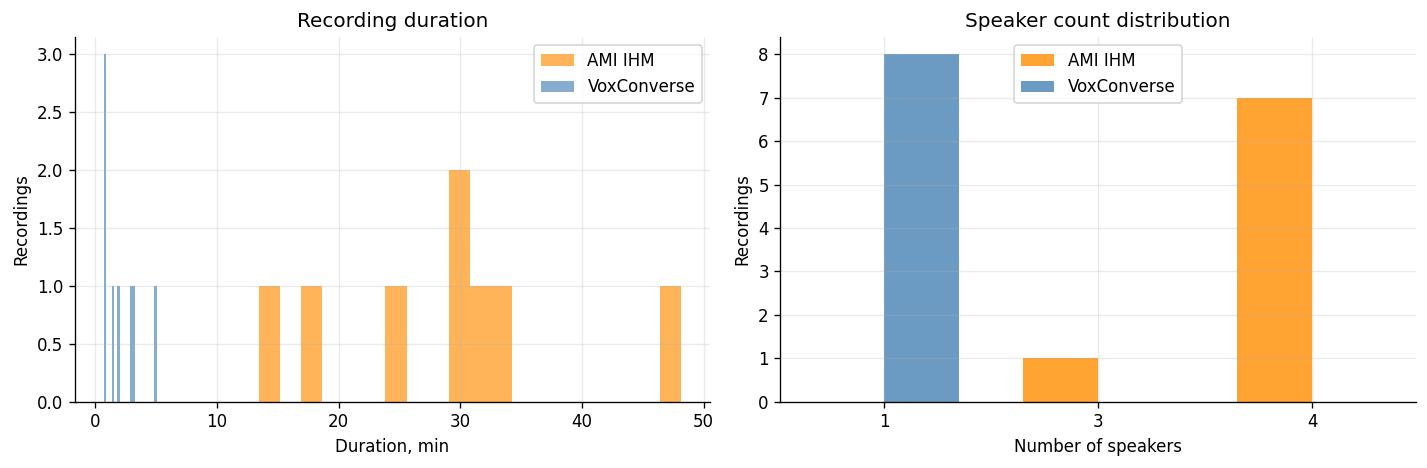

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"AMI IHM": "darkorange", "VoxConverse": "steelblue"}

for dataset, g in manifest.groupby("dataset"):
    axes[0].hist(g["duration_min"], bins=20, alpha=0.65, label=dataset, color=colors.get(dataset))
axes[0].set_title("Recording duration")
axes[0].set_xlabel("Duration, min")
axes[0].set_ylabel("Recordings")
axes[0].legend()

speaker_counts = sorted(manifest["n_speakers"].dropna().astype(int).unique())
x = np.arange(len(speaker_counts))
width = 0.35
for offset, (dataset, g) in zip([-width / 2, width / 2], manifest.groupby("dataset")):
    counts = g["n_speakers"].astype(int).value_counts().reindex(speaker_counts, fill_value=0)
    axes[1].bar(x + offset, counts.values, width=width, label=dataset, color=colors.get(dataset), alpha=0.8)
axes[1].set_title("Speaker count distribution")
axes[1].set_xlabel("Number of speakers")
axes[1].set_ylabel("Recordings")
axes[1].set_xticks(x)
axes[1].set_xticklabels(speaker_counts)
axes[1].legend()

plt.tight_layout()
plt.savefig(VIS_DIR / "01_eval_dataset_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Candidate 1: pyannote Community-1

`pyannote/speaker-diarization-community-1` is evaluated as the main self-hosted full-meeting diarization baseline. It is suitable for offline final processing because it supports unknown speaker counts and also supports `min_speakers`, `max_speakers`, and `num_speakers` when the expected number of meeting participants is known.

In [ ]:
def load_pyannote_model():
    from pyannote.audio import Pipeline

    pipeline = Pipeline.from_pretrained(
        "pyannote/speaker-diarization-community-1",
        token=HF_TOKEN if HF_TOKEN else None,
    )
    if DEVICE == "cuda":
        pipeline.to(torch.device("cuda"))
    return pipeline


def run_pyannote(pipeline, row: pd.Series) -> dict:
    audio_path = row["audio_path"]
    hyp_path = BASELINE_DIR / "predictions" / "pyannote_community_1" / row["dataset"].replace(" ", "_") / f"{row['id']}.rttm"
    hyp_path.parent.mkdir(parents=True, exist_ok=True)

    start = time.perf_counter()
    output = pipeline(audio_path)
    runtime_sec = time.perf_counter() - start

    diarization = getattr(output, "speaker_diarization", output)
    with open(hyp_path, "w") as f:
        diarization.write_rttm(f)

    hyp_df = read_rttm_df(hyp_path)
    hyp_speakers = hyp_df["speaker"].nunique() if not hyp_df.empty else 0
    scores = score_pair(Path(row["rttm_path"]), hyp_path, duration_sec=float(row["duration_sec"]))

    return {
        "model": "pyannote-community-1",
        "dataset": row["dataset"],
        "id": row["id"],
        "duration_sec": row["duration_sec"],
        "ref_speakers": row["n_speakers"],
        "hyp_speakers": hyp_speakers,
        "runtime_sec": runtime_sec,
        "rtf": runtime_sec / row["duration_sec"],
        "prediction_path": str(hyp_path),
        "failed": False,
        "error": "",
        **scores,
    }

In [ ]:
RUN_PYANNOTE = True

pyannote_rows = []
if RUN_PYANNOTE:
    pyannote_pipeline = load_pyannote_model()
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="pyannote Community-1"):
        try:
            pyannote_rows.append(run_pyannote(pyannote_pipeline, row))
        except Exception as e:
            pyannote_rows.append({
                "model": "pyannote-community-1",
                "dataset": row["dataset"],
                "id": row["id"],
                "duration_sec": row["duration_sec"],
                "ref_speakers": row["n_speakers"],
                "hyp_speakers": np.nan,
                "runtime_sec": np.nan,
                "rtf": np.nan,
                "prediction_path": "",
                "failed": True,
                "error": str(e),
                "der": np.nan,
                "jer": np.nan,
                "missed_detection": np.nan,
                "false_alarm": np.nan,
                "confusion": np.nan,
                "total": np.nan,
            })
    del pyannote_pipeline
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

pyannote_df = pd.DataFrame(pyannote_rows)
pyannote_df.to_csv(BASELINE_DIR / "pyannote_community_1.csv", index=False)
pyannote_df.head()

pyannote Community-1:   0%|          | 0/16 [00:00<?, ?it/s]

,model,dataset,id,duration_sec,ref_speakers,hyp_speakers,runtime_sec,rtf,prediction_path,failed,error,der,jer,missed_detection,false_alarm,confusion,total_speaker_time
0,pyannote-community-1,AMI IHM,EN2002c,2889.639938,3,4,187.119253,0.064755,data/baselines/diarization/predictions/pyannot...,False,,0.312822,0.330755,0.239875,0.009739,0.063208,3373.00
1,pyannote-community-1,AMI IHM,IS1009a,805.720000,4,5,26.804814,0.033268,data/baselines/diarization/predictions/pyannot...,False,,0.271410,0.409657,0.126545,0.032666,0.112200,704.10
2,pyannote-community-1,AMI IHM,ES2004a,1049.040062,4,6,39.889618,0.038025,data/baselines/diarization/predictions/pyannot...,False,,0.353247,0.369629,0.175954,0.026016,0.151277,934.05
3,pyannote-community-1,AMI IHM,TS3003a,1476.390063,4,5,64.435730,0.043644,data/baselines/diarization/predictions/pyannot...,False,,0.340904,0.667073,0.127827,0.036067,0.177009,1036.95
4,pyannote-community-1,AMI IHM,EN2002b,1786.590000,4,5,86.004166,0.048139,data/baselines/diarization/predictions/pyannot...,False,,0.349209,0.394736,0.246324,0.018394,0.084491,1965.30


## 4. Candidate 2: NVIDIA Streaming Sortformer v2.1

`nvidia/diar_streaming_sortformer_4spk-v2.1` is evaluated as a chunk-aware self-hosted alternative. The model is limited to four speakers. This limitation is important for the target service because real meetings may have more participants, especially when listeners occasionally speak.

In [ ]:
def load_sortformer_model(latency_preset: str = "low"):
    from nemo.collections.asr.models import SortformerEncLabelModel

    model = SortformerEncLabelModel.from_pretrained("nvidia/diar_streaming_sortformer_4spk-v2.1")
    model.eval()
    if DEVICE == "cuda":
        model = model.to("cuda")

    if latency_preset == "low":
        # 1.04 s input-buffer latency in the model card.
        model.sortformer_modules.chunk_len = 6
        model.sortformer_modules.chunk_right_context = 7
        model.sortformer_modules.fifo_len = 188
        model.sortformer_modules.spkcache_update_period = 144
        model.sortformer_modules.spkcache_len = 188
    elif latency_preset == "high":
        # 30.4 s input-buffer latency in the model card, usually better for offline scoring.
        model.sortformer_modules.chunk_len = 340
        model.sortformer_modules.chunk_right_context = 40
        model.sortformer_modules.fifo_len = 40
        model.sortformer_modules.spkcache_update_period = 300
        model.sortformer_modules.spkcache_len = 188
    else:
        raise ValueError("latency_preset must be 'low' or 'high'")

    model.sortformer_modules._check_streaming_parameters()
    return model


def normalize_sortformer_segments(predicted_segments):
    segments = []
    for seg in predicted_segments:
        if isinstance(seg, str):
            parts = seg.replace(",", " ").split()
            start, end, speaker = float(parts[0]), float(parts[1]), parts[2]
        elif isinstance(seg, (tuple, list)):
            start, end, speaker = float(seg[0]), float(seg[1]), str(seg[2])
        elif isinstance(seg, dict):
            start = float(seg.get("start", seg.get("begin", 0.0)))
            end = float(seg.get("end", seg.get("stop", 0.0)))
            speaker = str(seg.get("speaker", seg.get("label", "speaker_0")))
        else:
            raise TypeError(f"Unsupported segment type: {type(seg)}")
        if end > start:
            segments.append((start, end, speaker))
    return segments


def run_sortformer(model, row: pd.Series, latency_preset: str) -> dict:
    audio_path = row["audio_path"]
    hyp_path = BASELINE_DIR / "predictions" / f"sortformer_v2_1_{latency_preset}" / row["dataset"].replace(" ", "_") / f"{row['id']}.rttm"
    hyp_path.parent.mkdir(parents=True, exist_ok=True)

    start = time.perf_counter()
    predicted = model.diarize(audio=[audio_path], batch_size=1)
    runtime_sec = time.perf_counter() - start

    segments = normalize_sortformer_segments(predicted[0])
    write_segments_rttm(segments, hyp_path, uri=row["id"])

    hyp_df = read_rttm_df(hyp_path)
    hyp_speakers = hyp_df["speaker"].nunique() if not hyp_df.empty else 0
    scores = score_pair(Path(row["rttm_path"]), hyp_path, duration_sec=float(row["duration_sec"]))

    return {
        "model": f"sortformer-v2.1-{latency_preset}",
        "dataset": row["dataset"],
        "id": row["id"],
        "duration_sec": row["duration_sec"],
        "ref_speakers": row["n_speakers"],
        "hyp_speakers": hyp_speakers,
        "runtime_sec": runtime_sec,
        "rtf": runtime_sec / row["duration_sec"],
        "prediction_path": str(hyp_path),
        "failed": False,
        "error": "",
        **scores,
    }

In [ ]:
RUN_SORTFORMER = True
SORTFORMER_LATENCY_PRESET = "low"  # use "high" for the 30.4 s configuration from the model card

sortformer_rows = []
if RUN_SORTFORMER:
    sortformer_model = load_sortformer_model(latency_preset=SORTFORMER_LATENCY_PRESET)
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc=f"Sortformer v2.1 {SORTFORMER_LATENCY_PRESET}"):
        try:
            sortformer_rows.append(run_sortformer(sortformer_model, row, SORTFORMER_LATENCY_PRESET))
        except Exception as e:
            sortformer_rows.append({
                "model": f"sortformer-v2.1-{SORTFORMER_LATENCY_PRESET}",
                "dataset": row["dataset"],
                "id": row["id"],
                "duration_sec": row["duration_sec"],
                "ref_speakers": row["n_speakers"],
                "hyp_speakers": np.nan,
                "runtime_sec": np.nan,
                "rtf": np.nan,
                "prediction_path": "",
                "failed": True,
                "error": str(e),
                "der": np.nan,
                "jer": np.nan,
                "missed_detection": np.nan,
                "false_alarm": np.nan,
                "confusion": np.nan,
                "total": np.nan,
            })
    del sortformer_model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

sortformer_df = pd.DataFrame(sortformer_rows)
sortformer_df.to_csv(BASELINE_DIR / f"sortformer_v2_1_{SORTFORMER_LATENCY_PRESET}.csv", index=False)
sortformer_df.head()

[NeMo W 2026-04-28 16:54:53 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: null
    sample_rate: 16000
    num_spks: 4
    session_len_sec: 90
    soft_label_thres: 0.5
    soft_targets: false
    labels: null
    batch_size: 4
    shuffle: true
    num_workers: 18
    validation_mode: false
    use_lhotse: false
    use_bucketing: false
    pin_memory: true
    window_stride: 0.01
    subsampling_factor: 8
    
[NeMo W 2026-04-28 16:54:53 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: null
    is_tarred: false
    tarred_audio_filepaths: null
    sample_rate: 16000
    num_spks: 4
    sess

[NeMo I 2026-04-28 16:54:54 save_restore_connector:286] Model SortformerEncLabelModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--diar_streaming_sortformer_4spk-v2.1/snapshots/fafaab5faa1617a0ca52d38dd3dc4bd636800d3d/diar_streaming_sortformer_4spk-v2.1.nemo.


Sortformer v2.1 low:   0%|          | 0/16 [00:00<?, ?it/s]

[NeMo I 2026-04-28 16:54:54 vad_utils:81] No postprocessing YAML file has been provided. Default postprocessing configurations will be applied.


[NeMo W 2026-04-28 16:54:54 dataloader:881] The following configuration keys are ignored by Lhotse dataloader: session_len_sec,num_spks,soft_label_thres

Diarizing: 0it [00:00, ?it/s]

Streaming Steps:   0%|          | 0/6021 [00:00<?, ?it/s]

Streaming Steps:   0%|          | 3/6021 [00:00<04:20, 23.13it/s]

Streaming Steps:   0%|          | 6/6021 [00:00<04:20, 23.12it/s]

Streaming Steps:   0%|          | 9/6021 [00:00<04:19, 23.15it/s]

Streaming Steps:   0%|          | 12/6021 [00:00<04:19, 23.12it/s]

Streaming Steps:   0%|          | 15/6021 [00:00<04:21, 22.96it/s]

Streaming Steps:   0%|          | 18/6021 [00:00<04:21, 22.96it/s]

Streaming Steps:   0%|          | 21/6021 [00:00<04:20, 23.03it/s]

Streaming Steps:   0%|          | 24/6021 [00:01<04:21, 22.95it/s]

Streaming Steps:   0%|          | 27/6021 [00:01<04:21, 22.89it/s]

Streaming Steps:   0%|          | 30/6021 [00:01<04:22, 22.85it/s]

Streaming Steps:   1%|          | 33/6021 [00:01<04:22, 22.81it/s]

Streaming S

...

[NeMo I 2026-04-28 17:17:01 vad_utils:81] No postprocessing YAML file has been provided. Default postprocessing configurations will be applied.



[NeMo W 2026-04-28 17:17:01 dataloader:881] The following configuration keys are ignored by Lhotse dataloader: session_len_sec,num_spks,soft_label_thres

Diarizing: 0it [00:00, ?it/s]

Streaming Steps:   0%|          | 0/413 [00:00<?, ?it/s]

Streaming Steps:   1%|          | 3/413 [00:00<00:17, 23.31it/s]

Streaming Steps:   1%|▏         | 6/413 [00:00<00:17, 23.06it/s]

Streaming Steps:   2%|▏         | 9/413 [00:00<00:17, 22.85it/s]

Streaming Steps:   3%|▎         | 12/413 [00:00<00:18, 22.27it/s]

Streaming Steps:   4%|▎         | 15/413 [00:00<00:17, 22.44it/s]

Streaming Steps:   4%|▍         | 18/413 [00:00<00:17, 22.51it/s]

Streaming Steps:   5%|▌         | 21/413 [00:00<00:17, 22.49it/s]

Streaming Steps:   6%|▌         | 24/413 [00:01<00:17, 22.50it/s]

Streaming Steps:   7%|▋         | 27/413 [00:01<00:17, 22.12it/s]

Streaming Steps:   7%|▋         | 30/413 [00:01<00:17, 22.15it/s]

Streaming Steps:   8%|▊         | 33/413 [00:01<00:16, 22.52it/s]

Streaming Steps:   9%|

[NeMo I 2026-04-28 17:17:19 vad_utils:81] No postprocessing YAML file has been provided. Default postprocessing configurations will be applied.



[NeMo W 2026-04-28 17:17:19 dataloader:881] The following configuration keys are ignored by Lhotse dataloader: session_len_sec,num_spks,soft_label_thres

Diarizing: 0it [00:00, ?it/s]

Streaming Steps:   0%|          | 0/632 [00:00<?, ?it/s]

Streaming Steps:   0%|          | 3/632 [00:00<00:28, 21.91it/s]

Streaming Steps:   1%|          | 6/632 [00:00<00:28, 22.19it/s]

Streaming Steps:   1%|▏         | 9/632 [00:00<00:27, 22.79it/s]

Streaming Steps:   2%|▏         | 12/632 [00:00<00:26, 22.99it/s]

Streaming Steps:   2%|▏         | 15/632 [00:00<00:26, 22.97it/s]

Streaming Steps:   3%|▎         | 18/632 [00:00<00:26, 22.90it/s]

Streaming Steps:   3%|▎         | 21/632 [00:00<00:26, 23.10it/s]

Streaming Steps:   4%|▍         | 24/632 [00:01<00:26, 23.17it/s]

Streaming Steps:   4%|▍         | 27/632 [00:01<00:26, 23.13it/s]

Streaming Steps:   5%|▍         | 30/632 [00:01<00:26, 22.53it/s]

Streaming Steps:   5%|▌         | 33/632 [00:01<00:26, 22.66it/s]

Streaming Steps:   6%|

,model,dataset,id,duration_sec,ref_speakers,hyp_speakers,runtime_sec,rtf,prediction_path,failed,error,der,jer,missed_detection,false_alarm,confusion,total_speaker_time
0,sortformer-v2.1-low,AMI IHM,EN2002c,2889.639938,3,4,267.534188,0.092584,data/baselines/diarization/predictions/sortfor...,False,,0.472932,0.458713,0.364305,0.011889,0.096739,3373.00
1,sortformer-v2.1-low,AMI IHM,IS1009a,805.720000,4,4,74.215197,0.092110,data/baselines/diarization/predictions/sortfor...,False,,0.237466,0.354905,0.181224,0.018605,0.037637,704.10
2,sortformer-v2.1-low,AMI IHM,ES2004a,1049.040062,4,4,97.630832,0.093067,data/baselines/diarization/predictions/sortfor...,False,,0.346930,0.389028,0.315990,0.005942,0.024999,934.05
3,sortformer-v2.1-low,AMI IHM,TS3003a,1476.390063,4,4,137.170154,0.092909,data/baselines/diarization/predictions/sortfor...,False,,0.340807,0.541265,0.304692,0.012151,0.023965,1036.95
4,sortformer-v2.1-low,AMI IHM,EN2002b,1786.590000,4,4,165.631725,0.092708,data/baselines/diarization/predictions/sortfor...,False,,0.442452,0.498027,0.361446,0.010787,0.070218,1965.30


## 5. Results

The summary table reports mean and median DER/JER because meeting recordings vary strongly in duration, number of speakers, and overlap. RTF is computed from total model runtime divided by total audio duration.

In [ ]:
result_files = [
    p for p in sorted(BASELINE_DIR.glob("*.csv"))
    if p.name not in {"summary_all_models.csv", "all_recording_results.csv"}
]
all_results = pd.concat([pd.read_csv(p) for p in result_files if p.name != "summary_all_models.csv"], ignore_index=True)
all_results = all_results.drop_duplicates(
    subset=["model", "dataset", "id"],
    keep="last"
)
all_results = all_results[~all_results["failed"].fillna(False)].copy()
all_results.to_csv(BASELINE_DIR / "all_recording_results.csv", index=False)

summary = summarize_scores(all_results)
summary.to_csv(BASELINE_DIR / "summary_all_models.csv", index=False)
summary.round(4)

,model,dataset,n_recordings,total_audio_h,mean_der,median_der,mean_jer,median_jer,speaker_count_acc,rtf,rtfx,failures
0,pyannote-community-1,AMI IHM,8,3.8192,0.2858,0.3049,0.3613,0.3502,0.000,0.0506,19.7463,0
1,sortformer-v2.1-low,AMI IHM,8,3.8192,0.3254,0.3439,0.3891,0.4069,0.875,0.0929,10.7631,0
2,sortformer-v2.1-low,VoxConverse,8,0.2823,0.0315,0.0265,0.0286,0.0233,0.625,0.0935,10.6900,0
3,pyannote-community-1,VoxConverse,8,0.2823,0.0770,0.0484,0.0639,0.0468,0.625,0.0234,42.7437,0


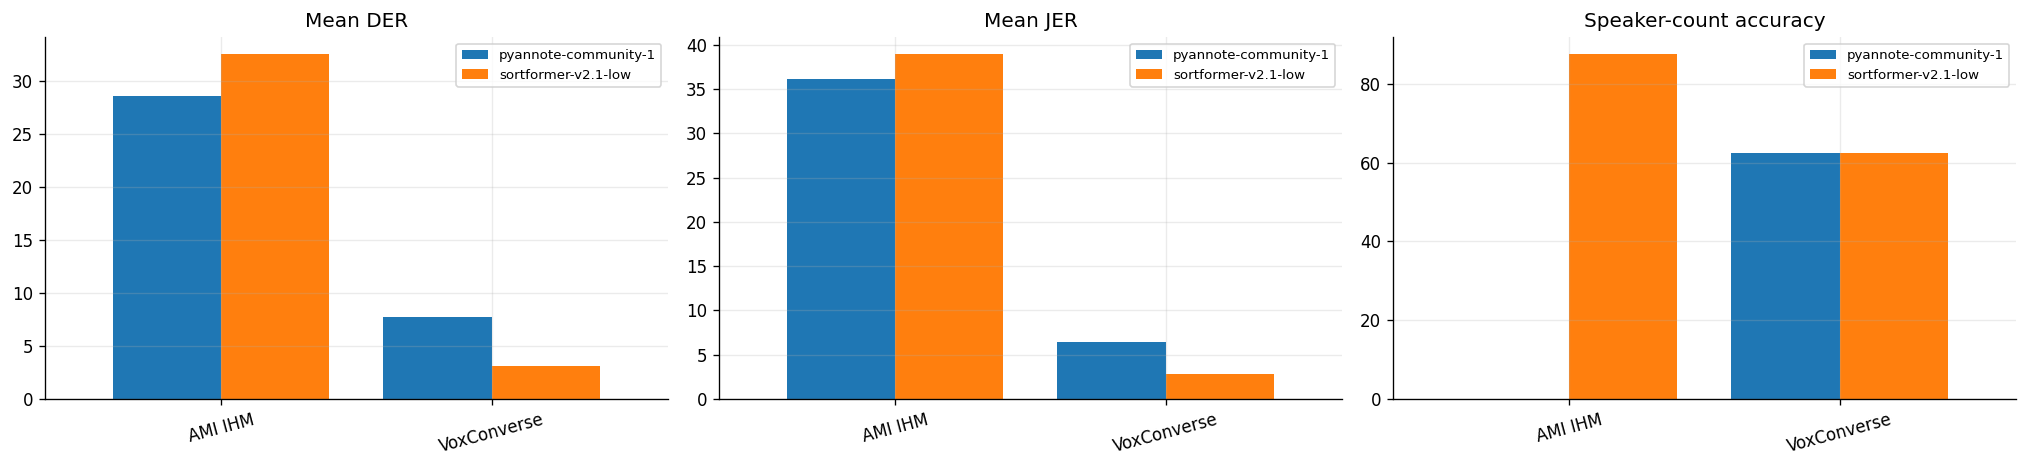

In [ ]:
plot_df = summary.copy()
plot_df["DER (%)"] = 100 * plot_df["mean_der"]
plot_df["JER (%)"] = 100 * plot_df["mean_jer"]
plot_df["Speaker count accuracy (%)"] = 100 * plot_df["speaker_count_acc"]

metrics = [("DER (%)", "Mean DER"), ("JER (%)", "Mean JER"), ("Speaker count accuracy (%)", "Speaker-count accuracy")]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, (metric, title) in zip(axes, metrics):
    pivot = plot_df.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "02_quality_summary.png", dpi=150, bbox_inches="tight")
plt.show()

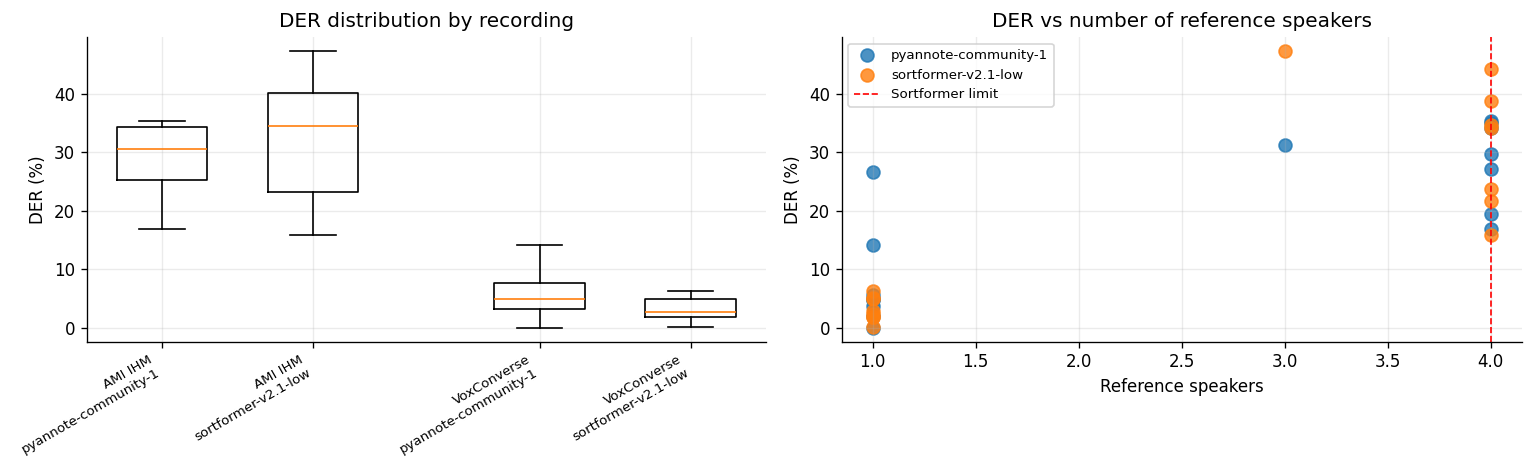

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models = list(all_results["model"].dropna().unique())
datasets = list(all_results["dataset"].dropna().unique())
positions = []
labels = []
data = []
pos = 1
for dataset in datasets:
    for model in models:
        vals = 100 * all_results[(all_results["dataset"] == dataset) & (all_results["model"] == model)]["der"].dropna()
        if len(vals):
            data.append(vals.values)
            positions.append(pos)
            labels.append(f"{dataset}\n{model}")
            pos += 1
    pos += 0.5
axes[0].boxplot(data, positions=positions, widths=0.6, showfliers=False)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
axes[0].set_title("DER distribution by recording")
axes[0].set_ylabel("DER (%)")

for model in models:
    g = all_results[all_results["model"] == model]
    axes[1].scatter(g["ref_speakers"], 100 * g["der"], label=model, s=60, alpha=0.8)
axes[1].axvline(4, color="red", linestyle="--", linewidth=1, label="Sortformer limit")
axes[1].set_title("DER vs number of reference speakers")
axes[1].set_xlabel("Reference speakers")
axes[1].set_ylabel("DER (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "03_der_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

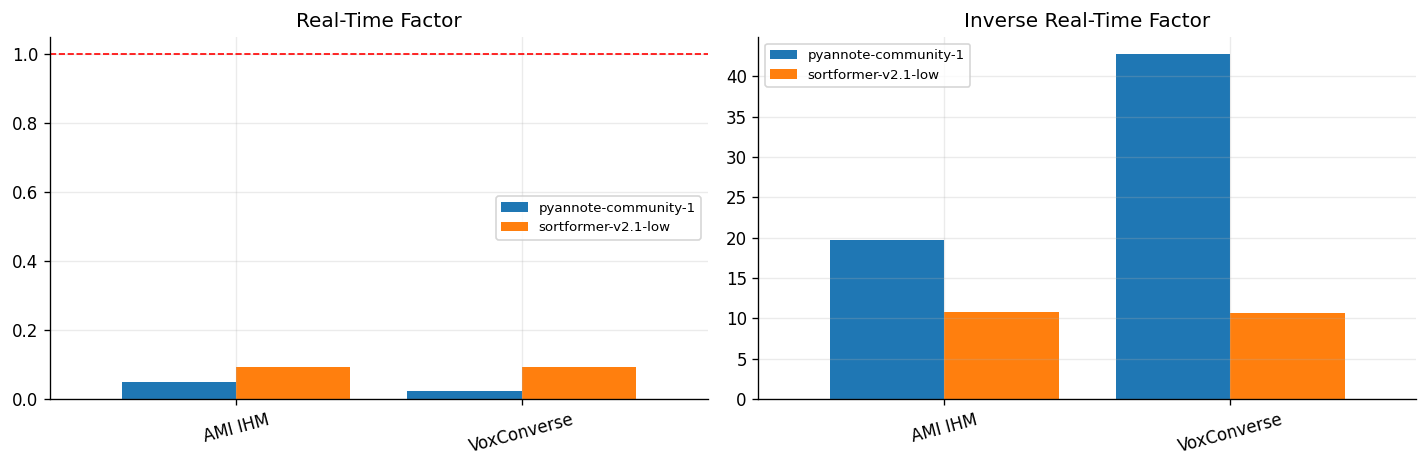

In [ ]:
speed_df = summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [(axes[0], "rtf", "Real-Time Factor"), (axes[1], "rtfx", "Inverse Real-Time Factor")]:
    pivot = speed_df.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
    if metric == "rtf":
        ax.axhline(1.0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig(VIS_DIR / "04_speed_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
worst = all_results.sort_values("der", ascending=False).head(10)
cols = ["model", "dataset", "id", "ref_speakers", "hyp_speakers", "der", "jer", "rtf"]
worst[cols].round(4)

,model,dataset,id,ref_speakers,hyp_speakers,der,jer,rtf
16,sortformer-v2.1-low,AMI IHM,EN2002c,3,4,0.4729,0.4587,0.0926
20,sortformer-v2.1-low,AMI IHM,EN2002b,4,4,0.4425,0.4980,0.0927
21,sortformer-v2.1-low,AMI IHM,IS1009c,4,4,0.3881,0.4248,0.0928
2,pyannote-community-1,AMI IHM,ES2004a,4,6,0.3532,0.3696,0.0380
4,pyannote-community-1,AMI IHM,EN2002b,4,5,0.3492,0.3947,0.0481
18,sortformer-v2.1-low,AMI IHM,ES2004a,4,4,0.3469,0.3890,0.0931
3,pyannote-community-1,AMI IHM,TS3003a,4,5,0.3409,0.6671,0.0436
19,sortformer-v2.1-low,AMI IHM,TS3003a,4,4,0.3408,0.5413,0.0929
0,pyannote-community-1,AMI IHM,EN2002c,3,4,0.3128,0.3308,0.0648
6,pyannote-community-1,AMI IHM,IS1009d,4,6,0.2971,0.3276,0.0509
